In [2]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
toe_to_MWh = 11.630

In [4]:
with open(Path.cwd().parent / 'config.basicrun.yaml', 'r') as f:
    params = yaml.safe_load(f)['industry']

In [5]:
sheet_names = {
    "Iron and steel": "ISI",
    "Chemicals Industry": "CHI",
    "Non-metallic mineral products": "NMM",
    "Pulp, paper and printing": "PPA",
    "Food, beverages and tobacco": "FBT",
    "Non Ferrous Metals": "NFM",
    "Transport equipment": "TRE",
    "Machinery equipment": "MAE",
    "Textiles and leather": "TEL",
    "Wood and wood products": "WWP",
    "Other industrial sectors": "OIS",
}
index = [
    "<100",
    "100-200",
    "200-500",
    ">500",
]
notes = {}

In [6]:
path = Path.cwd().parent / 'data' / 'jrc-idees-2021'

In [7]:
def load_idees_data(sector, country="EU27"):
    suffixes = {"out": "", "fec": "_fec", "ued": "_ued", "emi": "_emi"}
    sheets = {k: sheet_names[sector] + v for k, v in suffixes.items()}

    def usecols(x):
        return isinstance(x, str) or x == 2021

    idees = pd.read_excel(
        f"{path}/{country}/JRC-IDEES-2021_Industry_{country}.xlsx",
        sheet_name=list(sheets.values()),
        index_col=0,
        header=0,
        usecols=usecols,
    )

    for k, v in sheets.items():
        idees[k] = idees.pop(v).squeeze()
        idees[k] = idees[k][2021]

    return idees

In [8]:
notes

{}

In [9]:
def iron_and_steel():
    sector = "Iron and steel"
    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    ## Electric arc

    sector = "Electric arc"
    df[sector] = 0.0

    s_fec = idees["fec"][52:68]
    assert s_fec.index[0] == sector

    df.at["<100", sector] += s_fec.loc["Low-enthalpy heat"]

    subsector = "Steel: Smelters"
    s_fec = idees["fec"][63:68]
    s_ued = idees["ued"][63:68]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    # efficiency changes due to transforming all the smelters into methane
    key = "Natural gas and biogas"
    eff_met = s_ued.loc[key] / s_fec.loc[key]

    df.at[">500", sector] += s_ued[subsector] / eff_met

    # conversion to MWh/t material
    s_out = idees["out"][7:8]

    df.loc[:, sector] = df.loc[:, sector] * toe_to_MWh / s_out[sector]

    ## DRI + Electric arc
    # For primary route: DRI with H2 + EAF

    sector = "DRI + Electric arc"

    df[sector] = df["Electric arc"]

    # add H2 consumption for DRI at 1.7 MWh H2 /ton steel
    df.at[">500", sector] = params["H2_DRI"]

    ## Integrated steelworks
    # could be used in combination with CCS)
    # Assume existing fuels are kept, except for furnaces, refining, rolling, finishing
    # Ignore 'derived gases' since these are top gases from furnaces

    sector = "Integrated steelworks"

    df[sector] = 0.0

    s_fec = idees["fec"][3:50]
    assert s_fec.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    subsector = "Steel: Sinter/Pellet-making"

    s_fec = idees["fec"][14:20]
    s_ued = idees["ued"][14:20]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    sel = ["Natural gas and biogas", "Fuel oil", "Solids"]
    df.loc[">500", sector] += s_fec[sel].sum()

    subsector = "Steel: Blast /Basic oxygen furnace"

    s_fec = idees["fec"][20:26]
    s_ued = idees["ued"][20:26]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    sel = ["Natural gas and biogas", "Fuel oil", "Solids", "Coke"]
    df.loc[">500", sector] += s_fec[sel].sum()

    notes[sector + " >500"] = "The coke is used for heat, but is not fully replacabale in Integrated Steelworks"

    s_out = idees["out"][6:7]
    assert s_out.index[0] == sector

    # final energy consumption MWh/t material
    df.loc[:, sector] = df.loc[:, sector] * toe_to_MWh / s_out[sector]

    return df


In [10]:
def chemicals_industry():

    sector = "Chemicals Industry"
    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    # Basic chemicals

    sector = "Basic chemicals"

    df[sector] = 0.0

    s_fec = idees["fec"][3:9]
    assert s_fec.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    subsector = "Chemicals: Steam processing"

    s_fec = idees["fec"][23:34]
    s_ued = idees["ued"][23:34]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    # efficiency of natural gas
    eff_ch4 = s_ued["Natural gas and biogas"] / s_fec["Natural gas and biogas"]

    # replace all fec by methane
    df.loc["100-200", sector] += s_ued[subsector] / eff_ch4

    notes['Basic chemicals 100-200'] = "Some ambiguity, could also be in the 200-500 band; maybe match to validation"
    notes['Basic chemicals'] = "Did not subtract methanol and hydrogen demand yet"

    # convert from MtHVC/a to ktHVC/a
    s_out = params["HVC_production_today"] * 1e3
    df.loc[:, sector] = df.loc[:, sector] / s_out

    # Other chemicals

    sector = "Other chemicals"

    df[sector] = 0.0

    s_fec = idees["fec"][59:65]
    assert s_fec.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]


    subsector = "Chemicals: High-enthalpy heat processing"

    notes['Other chemicals'] = "Exogenously setting high-enthalpy heat processing to 100% electrification based on JRC data"

    s_out = idees["out"][9:10]
    assert sector in str(s_out.index)
    df.loc[:, sector] = df.loc[:, sector] * toe_to_MWh / s_out.values

    return df

In [11]:
def nonmetalic_mineral_products():

    sector = "Non-metallic mineral products"
    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    # Cement

    sector = "Cement"

    df[sector] = 0.0

    s_fec = idees["fec"][3:25]
    s_ued = idees["ued"][3:25]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]
    
    # redundant but aligns more clearly with original script
    df.loc[">500", sector] += s_fec["Biomass and waste"]
    df.loc[">500", sector] += (
        s_fec["Cement: Clinker production (kilns)"] - s_fec["Biomass and waste"]
    )

    s_out = idees["out"][7:8]
    assert sector in str(s_out.index)

    df.loc[:, sector] = df.loc[:, sector] * toe_to_MWh / s_out.values

    # Ceramics & other NMM

    sector = "Ceramics & other NMM"

    df[sector] = 0.0

    s_fec = idees["fec"][46:95]
    s_ued = idees["ued"][46:95]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    key = "Ceramics: Microwave drying and sintering"
    # the values are zero in new JRC-data -> assume here value from JRC-2015
    # eff_elec = s_ued[key] / s_fec[key]
    eff_elec = 11.6 / 26
    
    sel = [
        "Ceramics: Drying and sintering of raw material",
    ]
    df.loc[">500", sector] += s_ued[sel].sum() / eff_elec

    key = "Ceramics: Electric kiln"
    eff_elec = s_ued[key] / s_fec[key]

    df.loc[">500", sector] += s_ued["Ceramics: Primary production process"] / eff_elec

    key = "Ceramics: Electric furnace"
    eff_elec = s_ued[key] / s_fec[key]

    df.loc[">500", sector] += s_ued["Ceramics: Product finishing"] / eff_elec

    s_out = idees["out"][8:9]
    assert sector in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = df.loc[:, sector] * toe_to_MWh / s_out.values

    # Glass production

    sector = "Glass production"

    df[sector] = 0.0

    s_fec = idees["fec"][97:126]
    s_ued = idees["ued"][97:126]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    # Efficiency changes due to electrification
    key = "Glass: Electric melting tank"
    eff_elec = s_ued[key] / s_fec[key]

    df.loc[">500", sector] += s_ued["Glass: Melting tank"] / eff_elec

    key = "Glass: Annealing - electric"
    eff_elec = s_ued[key] / s_fec[key]

    sel = ["Glass: Forming"]
    df.loc[">500", sector] += s_ued[sel].sum() / eff_elec

    sel = ["Glass: Annealing"]
    df.loc["200-500", sector] += s_ued[sel].sum() / eff_elec

    sel = ["Glass: Finishing processes"]
    df.loc["<100", sector] += s_ued[sel].sum() / eff_elec

    s_out = idees["out"][9:10]
    assert sector in str(s_out.index)

    df.loc[:, sector] = df.loc[:, sector] * toe_to_MWh / s_out.values
    notes['glass'] = 'carried over efficiencies for electric heating, are these still valid for alternative carriers?'

    return df


In [12]:
def pulp_paper_printing():

    sector = "Pulp, paper and printing"
    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    sector = "Pulp production"

    df[sector] = 0.0

    s_fec = idees["fec"][3:29]
    s_ued = idees["ued"][3:29]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    eff_bio = s_ued["Biomass and waste"] / s_fec["Biomass and waste"]
    df.loc["100-200", sector] += s_ued["Pulp: Pulping thermal"] / eff_bio

    s_out = idees["out"][8:9]
    assert sector in str(s_out.index)

    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Pulp production (kt)"]
    )

    sector = "Paper production"

    df[sector] = 0.0

    s_fec = idees["fec"][30:80]
    s_ued = idees["ued"][30:80]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    s_fec = idees["fec"][55:66]
    s_ued = idees["ued"][55:66]
    assert s_fec.index[0] == "Paper: Paper machine - Steam use"
    assert s_ued.index[0] == "Paper: Paper machine - Steam use"

    # Efficiency changes due to biomass
    eff_bio = s_ued["Biomass and waste"] / s_fec["Biomass and waste"]
    df.loc["100-200", sector] += s_ued["Paper: Paper machine - Steam use"] / eff_bio

    s_fec = idees["fec"][68:79]
    s_ued = idees["ued"][68:79]
    assert s_fec.index[0] == "Paper: Product finishing - Steam use"
    assert s_ued.index[0] == "Paper: Product finishing - Steam use"

    eff_bio = s_ued["Biomass and waste"] / s_fec["Biomass and waste"]
    df.loc["100-200", sector] += s_ued["Paper: Product finishing - Steam use"] / eff_bio

    notes['paper'] = 'paper product finishing is assuming the efficiency of biomass'

    s_out = idees["out"][9:10]
    assert sector in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = df.loc[:, sector] * toe_to_MWh / s_out.values

    sector = "Printing and media reproduction"

    df[sector] = 0.0

    s_fec = idees["fec"][81:93]
    s_ued = idees["ued"][81:93]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]
    df.loc["<100", sector] += s_ued["Low-enthalpy heat"]

    s_out = idees["out"][10:11]
    assert sector in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = df.loc[:, sector] * toe_to_MWh / s_out.values

    return df

In [13]:
def food_beverages_tobacco():

    sector = "Food, beverages and tobacco"
    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    df[sector] = 0.0

    s_fec = idees["fec"][3:79]
    s_ued = idees["ued"][3:79]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    key = "Food: Direct Heat - Electric"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["200-500", sector] += s_ued["Food: Oven (direct heat)"] / eff_elec

    key = "Food: Process Heat - Electric"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["100-200", sector] += s_ued["Food: Specific process heat"] / eff_elec

    key = "Food: Electric drying"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["100-200", sector] += s_ued["Food: Drying"] / eff_elec

    # Steam processing goes all to biomass without change in efficiency
    df.loc["100-200", sector] += s_fec["Food: Steam processing"]

    s_out = idees["out"][3:4]
    assert "Physical output" in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Physical output (index)"]
    )

    return df


In [14]:
def non_ferrous_metals():

    sector = "Non Ferrous Metals"
    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    # Alumina

    sector = "Alumina production"

    df[sector] = 0.0

    s_fec = idees["fec"][3:31]
    s_ued = idees["ued"][3:31]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    s_fec = idees["fec"][14:25]
    s_ued = idees["ued"][14:25]
    assert s_fec.index[0] == "Alumina production: High-enthalpy heat"
    assert s_ued.index[0] == "Alumina production: High-enthalpy heat"

    eff_met = s_ued["Natural gas and biogas"] / s_fec["Natural gas and biogas"]
    df.loc[">500", sector] += (
        s_fec["Alumina production: High-enthalpy heat"] / eff_met
    )

    s_fec = idees["fec"][25:31]
    s_ued = idees["ued"][25:31]
    assert s_fec.index[0] == "Alumina production: Refining"
    assert s_ued.index[0] == "Alumina production: Refining"

    eff_elec = s_ued["Electricity"] / s_fec["Electricity"]
    df.loc[">500", sector] += s_ued["Alumina production: Refining"] / eff_elec

    s_out = idees["out"][9:10]
    assert sector in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Alumina production (kt)"]
    )

    notes['alumina >500'] = 'unclear which part of the process: if calcination, >500 is correct, if only digestion then it might be 100-500'

    # Aluminium - primary production    

    sector = "Aluminium - primary production"

    df[sector] = 0.0

    s_fec = idees["fec"][32:68]
    s_ued = idees["ued"][32:68]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    # Add aluminium  electrolysis (smelting
    df.loc[">500", sector] += s_fec["Aluminium electrolysis (smelting)"]

    # Efficiency changes due to electrification
    key = "Aluminium processing - Electric"
    eff_elec = s_ued[key] / s_fec[key]

    key = "Aluminium processing  (metallurgy e.g. cast house, reheating)"
    df.loc[">500", sector] += s_ued[key] / eff_elec

    key = "Aluminium finishing - Electric"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["<100", sector] += s_ued["Aluminium finishing"] / eff_elec

    s_out = idees["out"][11:12]
    assert sector in str(s_out.index)

    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Aluminium - primary production"]
    )

    # Aluminium - secondary production

    sector = "Aluminium - secondary production"

    df[sector] = 0.0

    s_fec = idees["fec"][70:112]
    s_ued = idees["ued"][70:112]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    # Efficiency changes due to electrification
    key = "Secondary aluminium - Electric"
    eff_elec = s_ued[key] / s_fec[key]
    key = "Secondary aluminium (incl. pre-treatment, remelting)"
    df.loc[">500", sector] += s_ued[key] / eff_elec

    key = "Aluminium processing - Electric"
    eff_elec = s_ued[key] / s_fec[key]
    key = "Aluminium processing  (metallurgy e.g. cast house, reheating)"
    df.loc[">500", sector] += s_ued[key] / eff_elec

    s_out = idees["out"][12:13]
    assert sector in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Aluminium - secondary production"]
    )

    # Other non-ferrous metals

    sector = "Other non-ferrous metals"

    df[sector] = 0.0

    s_fec = idees["fec"][113:156]
    s_ued = idees["ued"][113:156]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    key = "Metal production - Electric"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc[">500", sector] += s_ued["Other Metals: production"] / eff_elec

    key = "Metal processing - Electric"
    eff_elec = s_ued[key] / s_fec[key]

    key = "Metal processing  (metallurgy e.g. cast house, reheating)"
    df.loc[">500", sector] += s_ued[key] / eff_elec

    key = "Metal finishing - Electric"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["<100", sector] += s_ued["Metal finishing"] / eff_elec

    s_out = idees["out"][13:14]
    assert sector in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector]
        * toe_to_MWh
        / s_out["Other non-ferrous metals (kt lead eq.)"]
    )

    return df


In [15]:
def transport_equipment():
    sector = "Transport equipment"
    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    df[sector] = 0.0

    s_fec = idees["fec"][3:46]
    s_ued = idees["ued"][3:46]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    # Efficiency changes due to electrification
    key = "Trans. Eq.: Electric Foundries"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc[">500", sector] += s_ued["Trans. Eq.: Foundries"] / eff_elec

    key = "Trans. Eq.: Electric connection"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["<100", sector] += s_ued["Trans. Eq.: Connection techniques"] / eff_elec

    key = "Trans. Eq.: Heat treatment - Electric"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["200-500", sector] += s_ued["Trans. Eq.: Heat treatment"] / eff_elec

    df.loc["<100", sector] += s_fec["Trans. Eq.: General machinery"]
    df.loc["<100", sector] += s_fec["Trans. Eq.: Product finishing"]

    # Steam processing is supplied with biomass
    eff_biomass = s_ued["Biomass and waste"] / s_fec["Biomass and waste"]
    df.loc["<100", sector] += s_ued["Trans. Eq.: Steam processing"] / eff_biomass

    s_out = idees["out"][3:4]
    assert "Physical output" in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Physical output (index)"]
    )

    return df


In [16]:
def machinery_equipment():
    sector = "Machinery equipment"

    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    df[sector] = 0.0

    s_fec = idees["fec"][3:46]
    s_ued = idees["ued"][3:46]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    # Efficiency changes due to electrification
    key = "Mach. Eq.: Electric Foundries"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc[">500", sector] += s_ued["Mach. Eq.: Foundries"] / eff_elec

    key = "Mach. Eq.: Electric connection"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["<100", sector] += s_ued["Mach. Eq.: Connection techniques"] / eff_elec

    key = "Mach. Eq.: Heat treatment - Electric"
    eff_elec = s_ued[key] / s_fec[key]

    df.loc["200-500", sector] += s_ued["Mach. Eq.: Heat treatment"] / eff_elec

    df.loc["<100", sector] += s_fec["Mach. Eq.: General machinery"]
    df.loc["<100", sector] += s_fec["Mach. Eq.: Product finishing"]

    # Steam processing is supplied with biomass
    eff_biomass = s_ued["Biomass and waste"] / s_fec["Biomass and waste"]
    df.loc["100-200", sector] += s_ued["Mach. Eq.: Steam processing"] / eff_biomass

    s_out = idees["out"][3:4]
    assert "Physical output" in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Physical output (index)"]
    )

    return df


In [17]:
def textiles_and_leather():
    sector = "Textiles and leather"

    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    df[sector] = 0.0

    s_fec = idees["fec"][3:58]
    s_ued = idees["ued"][3:58]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    # Efficiency changes due to electrification
    # in new JRC data zero assume old data

    eff_elec = 73.7 / 146.6
    df.loc["100-200", sector] += s_ued["Textiles: Drying"] / eff_elec

    df.loc["<100", sector] += s_fec["Textiles: Electric general machinery"]
    df.loc["100-200", sector] += s_fec["Textiles: Finishing Electric"]

    # Steam processing is supplied with biomass
    eff_biomass = s_ued[15:26]["Biomass and waste"] / s_fec[15:26]["Biomass and waste"]
    df.loc["100-200", sector] += (
        s_ued["Textiles: Pretreatment with steam"] / eff_biomass
    )
    df.loc["100-200", sector] += (
        s_ued["Textiles: Wet processing with steam"] / eff_biomass
    )

    s_out = idees["out"][3:4]
    assert "Physical output" in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Physical output (index)"]
    )

    return df


In [18]:
def wood_and_wood_products():
    sector = "Wood and wood products"

    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    df[sector] = 0.0

    s_fec = idees["fec"][3:47]
    s_ued = idees["ued"][3:47]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    # Efficiency changes due to electrification
    key = "Wood: Electric drying"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["<100", sector] += s_ued["Wood: Drying"] / eff_elec

    df.loc["<100", sector] += s_fec["Wood: Electric mechanical processes"]
    df.loc["<100", sector] += s_fec["Wood: Finishing Electric"]

    # Steam processing is supplied with biomass
    eff_biomass = s_ued[15:25]["Biomass and waste"] / s_fec[15:25]["Biomass and waste"]
    df.loc["100-200", sector] += (
        s_ued["Wood: Specific processes with steam"] / eff_biomass
    )

    s_out = idees["out"][3:4]
    assert "Physical output" in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Physical output (index)"]
    )

    return df

In [19]:
def other_industrial_sectors():
    sector = "Other industrial sectors"
    idees = load_idees_data(sector)

    df = pd.DataFrame(index=index)

    df[sector] = 0.0

    s_fec = idees["fec"][3:68]
    s_ued = idees["ued"][3:68]
    assert s_fec.index[0] == sector
    assert s_ued.index[0] == sector

    df.loc["<100", sector] += s_fec["Low-enthalpy heat"]

    # Efficiency changes due to electrification
    key = "Other Industrial sectors: Electric processing"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["200-500", sector] += (
        s_ued["Other Industrial sectors: Process heating"] / eff_elec
    )

    key = "Other Industries: Electric drying"
    eff_elec = s_ued[key] / s_fec[key]
    df.loc["100-200", sector] += s_ued["Other Industrial sectors: Drying"] / eff_elec

    # Diesel motors are electrified
    key = "Other Industrial sectors: Diesel motors (incl. biofuels)"
    df.loc["<100", sector] += s_fec[key]

    # Steam processing is supplied with biomass
    eff_biomass = s_ued[15:25]["Biomass and waste"] / s_fec[15:25]["Biomass and waste"]
    df.loc["100-200", sector] += (
        s_ued["Other Industrial sectors: Steam processing"] / eff_biomass
    )

    s_out = idees["out"][3:4]
    assert "Physical output" in str(s_out.index)

    # MWh/t material
    df.loc[:, sector] = (
        df.loc[:, sector] * toe_to_MWh / s_out["Physical output (index)"]
    )

    return df


In [20]:

df = pd.concat(
    [
        iron_and_steel(),
        chemicals_industry(),
        nonmetalic_mineral_products(),
        pulp_paper_printing(),
        food_beverages_tobacco(),
        non_ferrous_metals(),
        transport_equipment(),
        machinery_equipment(),
        textiles_and_leather(),
        wood_and_wood_products(),
        other_industrial_sectors(),
    ],
    axis=1,
)

df

,Electric arc,DRI + Electric arc,Integrated steelworks,Basic chemicals,Other chemicals,Cement,Ceramics & other NMM,Glass production,Pulp production,Paper production,...,"Food, beverages and tobacco",Alumina production,Aluminium - primary production,Aluminium - secondary production,Other non-ferrous metals,Transport equipment,Machinery equipment,Textiles and leather,Wood and wood products,Other industrial sectors
<100,0.004876,0.004876,0.005924,0.015901,0.142351,0.004079,0.005822,0.135662,0.035776,0.030866,...,0.031166,0.016556,0.540006,0.005534,0.430047,0.166604,0.097797,0.122134,0.461238,0.039641
100-200,0.000000,0.000000,0.000000,0.298596,0.000000,0.000000,0.000000,0.000000,2.514499,2.249999,...,0.887531,0.000000,0.000000,0.000000,0.000000,0.000000,0.068156,0.446977,1.642243,0.074479
200-500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.113601,0.000000,0.000000,...,0.079574,0.000000,0.000000,0.000000,0.000000,0.074759,0.076446,0.000000,0.000000,0.078061
>500,0.161758,1.700000,0.655360,0.000000,0.000000,0.434225,0.479006,1.180946,0.000000,0.000000,...,0.000000,5.003653,13.695545,1.146209,2.674325,0.052331,0.053512,0.000000,0.000000,0.000000


In [21]:
production = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_production_per_country.csv', index_col=0
).sum()

In [22]:
production.sort_values()

Methanol                               1581.84
Aluminium - primary production         2035.89
Aluminium - secondary production       2903.25
Alumina production                     7086.40
Chlorine                              10102.68
Printing and media reproduction       10656.76
Pharmaceutical products etc.          11445.55
Other non-ferrous metals              13722.58
Ammonia                               17053.44
Other chemicals                       29883.89
Wood and wood products                37159.19
Glass production                      38799.80
Pulp production                       41245.27
HVC                                   54837.16
Electric arc                          70849.11
Textiles and leather                  77278.90
Paper production                      93204.00
Integrated steelworks                 96164.07
Cement                               188980.99
Food, beverages and tobacco          273958.15
Transport equipment                  339468.14
Ceramics & ot

In [23]:
df.mul(production, axis=1).sum(axis=1) / 1e3

<100       232.184684
100-200    775.460591
200-500    184.210472
>500       523.174435
dtype: float64

In [24]:
ed = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_per_country_today.csv', index_col=0, header=[0,1]
)

In [25]:
ed

AL                                 \
            Alumina production Aluminium - primary production   
TWh/a                                                           
ammonia                    0.0                            0.0   
biomass                    0.0                            0.0   
electricity                0.0                            0.0   
gas                        0.0                            0.0   
heat                       0.0                            0.0   
hydrogen                   0.0                            0.0   
liquid                     0.0                            0.0   
other                      0.0                           -0.0   
solid                      0.0                            0.0   
waste                      0.0                            0.0   

                                                                    \
            Aluminium - secondary production Ammonia        Cement   
TWh/a                                                                
ammonia                                  0.0     0.0  0.000000e+00   
biomass                                  0.0     0.0  1.906630e-03   
electricity                              0.0     0.0  2.817006e-03   
gas                                      0.0     0.0  9.535426e-03   
heat                                     0.0     0.0  2.144612e-04   
hydrogen                                 0.0     0.0  0.000000e+00   
liquid                                   0.0     0.0  6.124493e-03   
other                                   -0.0     0.0 -1.255286e-18   
solid                                    0.0     0.0  3.262325e-03   
waste                                    0.0     0.0  4.798959e-03   

                                                          \
            Ceramics & other NMM  Chlorine  Electric arc   
TWh/a                                                      
ammonia             0.000000e+00  0.000000  0.000000e+00   
biomass             1.860580e-03  0.000000  1.745756e-04   
electricity         5.759261e-03  0.011160  6.071055e-02   
gas                 1.285101e-02  0.000000  3.241683e-02   
heat                4.057514e-04  0.000000  2.162600e-03   
hydrogen            0.000000e+00 -0.002905  0.000000e+00   
liquid              5.542503e-03  0.000000  2.096589e-03   
other              -6.306161e-19  0.000000 -2.724209e-18   
solid               3.401920e-03  0.000000  1.406566e-03   
waste               3.604022e-03  0.000000  5.335114e-06   

                                                          ...              XK  \
            Food, beverages and tobacco Glass production  ... Other chemicals   
TWh/a                                                     ...                   
ammonia                    0.000000e+00     0.000000e+00  ...    0.000000e+00   
biomass                    2.959699e-02     3.763335e-05  ...    3.283821e-05   
electricity                2.006112e-01     3.650089e-03  ...    9.666255e-04   
gas                        2.649908e-01     6.422005e-03  ...    1.323223e-03   
heat                       2.977809e-02     0.000000e+00  ...    5.014533e-04   
hydrogen                   0.000000e+00     0.000000e+00  ...    0.000000e+00   
liquid                     3.005989e-02     4.658897e-04  ...    4.316407e-04   
other                      2.431179e-17    -9.447981e-20  ...   -2.187968e-19   
solid                      2.391242e-02     1.656717e-03  ...    2.662675e-04   
waste                      1.536753e-04     0.000000e+00  ...    2.949609e-05   

                                                               \
            Other industrial sectors Other non-ferrous metals   
TWh/a                                                           
ammonia                 0.000000e+00                      0.0   
biomass                 1.848777e-02                      0.0   
electricity             1.937139e-01                      0.0   
gas                     9.114439e-02          

In [26]:
set(ed.columns.get_level_values(1).unique()) == set(production.index)

True

In [27]:
production.sort_values()

Methanol                               1581.84
Aluminium - primary production         2035.89
Aluminium - secondary production       2903.25
Alumina production                     7086.40
Chlorine                              10102.68
Printing and media reproduction       10656.76
Pharmaceutical products etc.          11445.55
Other non-ferrous metals              13722.58
Ammonia                               17053.44
Other chemicals                       29883.89
Wood and wood products                37159.19
Glass production                      38799.80
Pulp production                       41245.27
HVC                                   54837.16
Electric arc                          70849.11
Textiles and leather                  77278.90
Paper production                      93204.00
Integrated steelworks                 96164.07
Cement                               188980.99
Food, beverages and tobacco          273958.15
Transport equipment                  339468.14
Ceramics & ot

In [28]:
inter = df.columns.intersection(production.index)
inter

Index(['Electric arc', 'Integrated steelworks', 'Other chemicals', 'Cement',
       'Ceramics & other NMM', 'Glass production', 'Pulp production',
       'Paper production', 'Printing and media reproduction',
       'Food, beverages and tobacco', 'Alumina production',
       'Aluminium - primary production', 'Aluminium - secondary production',
       'Other non-ferrous metals', 'Transport equipment',
       'Machinery equipment', 'Textiles and leather', 'Wood and wood products',
       'Other industrial sectors'],
      dtype='object')

In [29]:
only_df = df.columns.difference(production.index)
only_df

Index(['Basic chemicals', 'DRI + Electric arc'], dtype='object')

In [30]:
all = production[['HVC', 'Methanol', 'Chlorine', 'Ammonia']].sum().sum()
hvc_share = production['HVC'] / all
meth_share = production['Methanol'] / all
chlor_share = production['Chlorine'] / all
ammonia_share = production['Ammonia'] / all

In [31]:
fixed = df.copy()

fixed['HVC'] = df['Basic chemicals'] * hvc_share
fixed['Methanol'] = df['Basic chemicals'] * meth_share
fixed['Chlorine'] = df['Other chemicals'] * chlor_share
fixed['Ammonia'] = df['Other chemicals'] * ammonia_share
fixed.drop(columns=['Basic chemicals'], inplace=True)
fixed['Electric arc'] = fixed['Electric arc'] + fixed['DRI + Electric arc']
fixed.drop(columns=['DRI + Electric arc'], inplace=True)

In [32]:
heat_demands = fixed.mul(production, axis=1).sum(axis=1) / 1e3

In [33]:
heat_demands.sum()

1847.8136589158503

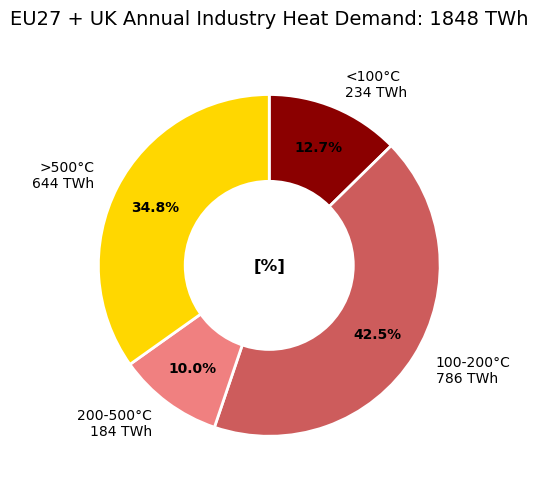

In [34]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Define colors from dark red to yellow
colors = ['#8B0000', '#CD5C5C', '#F08080', '#FFD700']

# Adjustable radius parameter for percentage labels
percentage_radius = 0.75

# Create labels with temperature ranges and totals (rounded to integers)
labels = []
percentages = []
total = heat_demands.sum()
for temp, value in heat_demands.items():
    percentage = (value / total) * 100
    labels.append(f'{temp}°C\n{int(round(value))} TWh')
    percentages.append(f'{percentage:.1f}%')

# Create pie chart with white edges and donut hole
wedges, texts = ax.pie(heat_demands, 
                        labels=labels,
                        colors=colors,
                        startangle=90,
                        counterclock=False,
                        labeldistance=1.15,
                        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
                        pctdistance=percentage_radius,
                        textprops={'fontsize': 10})

# Add percentage labels on the pie pieces
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = percentage_radius * wedge.r * plt.np.cos(plt.np.deg2rad(angle))
    y = percentage_radius * wedge.r * plt.np.sin(plt.np.deg2rad(angle))
    ax.text(x, y, percentages[i], ha='center', va='center', fontsize=10, fontweight='bold')

# Create donut hole (white circle in the middle)
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
ax.add_artist(centre_circle)

# Add [%] text in the center
ax.text(0, 0, '[%]', ha='center', va='center', fontsize=12, fontweight='bold')

ax.set_title('EU27 + UK Annual Industry Heat Demand: {} TWh'.format(int(round(total))), fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('temperature_band_pie.pdf')
plt.show()

In [35]:
production

Electric arc                          70849.11
Integrated steelworks                 96164.07
Other chemicals                       29883.89
Pharmaceutical products etc.          11445.55
Cement                               188980.99
Ceramics & other NMM                 341867.60
Glass production                      38799.80
Pulp production                       41245.27
Paper production                      93204.00
Printing and media reproduction       10656.76
Food, beverages and tobacco          273958.15
Alumina production                     7086.40
Aluminium - primary production         2035.89
Aluminium - secondary production       2903.25
Other non-ferrous metals              13722.58
Transport equipment                  339468.14
Machinery equipment                  671303.00
Textiles and leather                  77278.90
Wood and wood products                37159.19
Other industrial sectors            1041564.12
Ammonia                               17053.44
HVC          

In [36]:
only_prod = production.index.difference(df.columns)
only_prod

Index(['Ammonia', 'Chlorine', 'HVC', 'Methanol',
       'Pharmaceutical products etc.'],
      dtype='object')